# Tutorial 07 — From Transformers to Language Models

### From Machine Learning to Foundation Models · Hands-On AI for Power & Energy Systems

> **How does predicting the next token create a language model?**

---

## 1. Why this matters

Nothing new is introduced in this notebook. The architecture is the
decoder-only Transformer from tutorial 06, with a causal mask. The only change
is the data — text instead of load — and the read-out: a probability
distribution over a vocabulary instead of a number in megawatts.

That is the point. Students routinely believe a language model is a special
kind of system. It is not: it is the same block, trained on the same
next-element objective, on a different modality. Once you have seen a
0.4-million-parameter GPT trained on 270 kB of power-systems text produce
recognisable operator-log entries, the 400-billion-parameter version stops
being mysterious and becomes a question of scale — which is exactly the right
frame for tutorials 08 and 09.

We also measure a small scaling law ourselves, and then argue carefully about
what scaling does and does not give you.

## 2. Historical context

GPT-1 (2018) had 117 M parameters and showed that generative pretraining plus
fine-tuning beat task-specific architectures. GPT-2 (2019, 1.5 B) showed the
fine-tuning step could sometimes be skipped. GPT-3 (2020, 175 B) made
in-context learning a headline capability: describe a task in the prompt and
the model does it, with no weight update at all. InstructGPT (2022) added
instruction tuning and RLHF, which is what turned a text completer into
something that answers questions.

Kaplan et al. (2020) fitted power laws relating loss to parameters, data and
compute. Hoffmann et al. (2022) — Chinchilla — corrected the trade-off,
showing that models of that era were badly under-trained on data. Both are
worth reading, in that order.

## 3. Learning objectives

By the end of this notebook you can:

- explain tokenization and compare character-level with subword vocabularies;
- explain the context window and why it is a hard architectural limit;
- write the next-token objective and explain teacher forcing;
- interpret cross-entropy and perplexity;
- train a small GPT and watch text emerge from noise;
- control sampling with temperature, top-k and top-p, and say what each does;
- measure a scaling law and state precisely what scaling does *not* buy.

In [1]:
from __future__ import annotations

import math
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from ai_power_course import diagrams
from ai_power_course.config import fast_mode, offline_mode, scaled, set_seed
from ai_power_course.corpus import corpus_path, write_corpus
from ai_power_course.models.tinygpt import CharTokenizer, TinyGPT, TinyGPTConfig, generate
from ai_power_course.models.training import count_parameters
from ai_power_course.plotting import COLORS, use_course_style

warnings.filterwarnings("ignore", category=FutureWarning)
use_course_style()
set_seed()
torch.set_num_threads(4)
print(f"reduced (CI) configuration: {fast_mode()}")

reduced (CI) configuration: False


## 4. The corpus

A language model is mostly its data, so start there.

In [2]:
path = corpus_path()
if not path.exists():
    write_corpus()
text = path.read_text(encoding="utf-8")

print(f"corpus: {path.name}, {len(text):,} characters, {len(set(text))} distinct symbols")
print("\nPROVENANCE ---------------------------------------------------------------")
print("Written for this course, MIT licensed with the repository. The handbook")
print("sections are genuine technical prose; the operator logs, disturbance reports")
print("and asset records are SYNTHETIC, generated from templates. They describe no")
print("real substation, asset or event.")
print("\nWhy self-written: real operator logs are confidential and scraped technical")
print("documentation usually cannot be redistributed. The cost is a tiny corpus —")
print("270 kB against the several terabytes behind a modern LLM — which is why the")
print("model here is tiny too, and why we are explicit that the gap is data and")
print("compute rather than a different idea.")
print("--------------------------------------------------------------------------")
print(f"\n{text[:420]}")

corpus: power_systems_corpus.txt, 275,906 characters, 76 distinct symbols

PROVENANCE ---------------------------------------------------------------
Written for this course, MIT licensed with the repository. The handbook
sections are genuine technical prose; the operator logs, disturbance reports
and asset records are SYNTHETIC, generated from templates. They describe no
real substation, asset or event.

Why self-written: real operator logs are confidential and scraped technical
documentation usually cannot be redistributed. The cost is a tiny corpus —
270 kB against the several terabytes behind a modern LLM — which is why the
model here is tiny too, and why we are explicit that the gap is data and
compute rather than a different idea.
--------------------------------------------------------------------------

POWER SYSTEMS HANDBOOK

PER-UNIT SYSTEM
The per-unit system expresses electrical quantities as fractions of a chosen
base. A base apparent power S_base and a base voltage V_base

## 5. Tokenization

A model consumes integers. Tokenization is the map from text to integers, and
it is a genuine design decision, not plumbing.

In [3]:
tokenizer = CharTokenizer(text)
sample_text = "LOG 07:15 Nordfeld 380 kV | voltage 1.024 pu"
ids = tokenizer.encode(sample_text)

print(f"vocabulary size: {tokenizer.vocab_size}")
print(f"characters     : {''.join(tokenizer.chars)!r}\n")
print(f"text  : {sample_text}")
print(f"ids   : {ids[:24]} ...  ({len(ids)} tokens)")
print(f"back  : {tokenizer.decode(ids)}")
assert tokenizer.decode(ids) == sample_text

vocabulary size: 76
characters     : '\n ()*,-./0123456789:;=ABCDEFGHIKLMNOPQRSTUVWXYZ^_abcdefghijklmnopqrstuvwxyz|'

text  : LOG 07:15 Nordfeld 380 kV | voltage 1.024 pu
ids   : [32, 35, 28, 1, 9, 16, 19, 10, 14, 1, 34, 63, 66, 52, 54, 53, 60, 52, 1, 12, 17, 9, 1, 59] ...  (44 tokens)
back  : LOG 07:15 Nordfeld 380 kV | voltage 1.024 pu


### Character level versus subword

Real models use subword vocabularies (BPE, SentencePiece) of 30 k–150 k
tokens. Let us compare against a real one rather than describe it.

In [4]:
subword = None
if not offline_mode():
    try:
        from transformers import AutoTokenizer

        subword = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")
    except Exception as exc:  # noqa: BLE001 - offline or rate-limited is fine
        print(f"(subword tokenizer unavailable: {type(exc).__name__}; skipping comparison)")

if subword is not None:
    subword_ids = subword.encode(sample_text)
    pieces = [subword.decode([i]) for i in subword_ids]
    comparison = pd.DataFrame(
        {
            "vocabulary size": [tokenizer.vocab_size, subword.vocab_size],
            "tokens for the sample": [len(ids), len(subword_ids)],
            "chars per token": [len(sample_text) / len(ids),
                                len(sample_text) / len(subword_ids)],
            "embedding rows at d=512": [tokenizer.vocab_size * 512, subword.vocab_size * 512],
        },
        index=["character level (ours)", "subword (SmolLM2)"],
    )
    display(comparison.round(2))
    print("how the subword tokenizer splits it:")
    print("  " + " | ".join(repr(p) for p in pieces))

,vocabulary size,tokens for the sample,chars per token,embedding rows at d=512
character level (ours),76,44,1.00,38912
subword (SmolLM2),49152,24,1.83,25165824


how the subword tokenizer splits it:
  'LOG' | ' ' | '0' | '7' | ':' | '1' | '5' | ' Nord' | 'feld' | ' ' | '3' | '8' | '0' | ' k' | 'V' | ' |' | ' voltage' | ' ' | '1' | '.' | '0' | '2' | '4' | ' pu'


The trade is explicit:

| | character | subword |
|---|---|---|
| vocabulary | ~100 | 30 k–150 k |
| sequence length for the same text | long | ~4x shorter |
| embedding table | tiny | large |
| unknown symbols | impossible | impossible (falls back to bytes) |
| must learn spelling | yes | mostly no |

Since attention costs $O(n^2)$, a 4x shorter sequence is a 16x cheaper
attention matrix. That is why every serious model pays for the large embedding
table. We use characters because a 76-symbol vocabulary is what a model this
small can actually learn.

**Tokenization leaks into behaviour.** Digits split inconsistently under BPE,
which is part of why LLMs are unreliable at arithmetic; and "1.024 pu" may
become three or four tokens with no relationship to its numeric value. For
engineering text full of numbers and units, this matters.

## 6. Next-token prediction

The entire objective:

$$\mathcal{L} = -\frac{1}{T}\sum_{t=1}^{T} \log p_\theta\big(x_t \mid x_{<t}\big)$$

Because of the causal mask, every position predicts its successor *at the same
time*. A sequence of length $T$ therefore yields $T$ training signals from one
forward pass. That is **teacher forcing**, and it is why the objective scales:
the supervision is free.

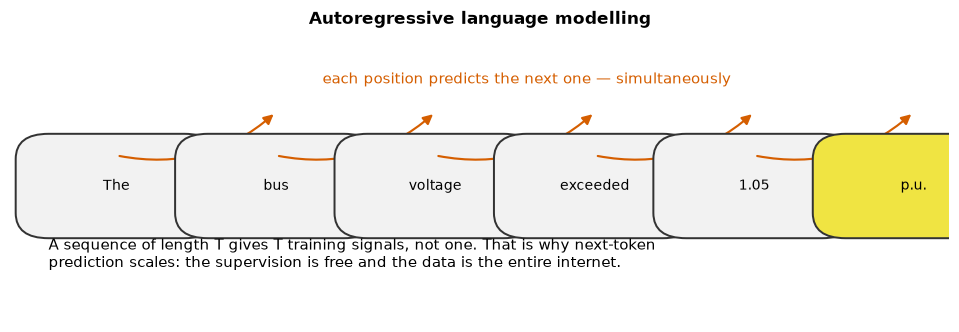

In [5]:
fig = diagrams.next_token_prediction()
plt.show()

In [6]:
data = torch.tensor(tokenizer.encode(text), dtype=torch.long)
n_train = int(0.9 * len(data))
train_data, valid_data = data[:n_train], data[n_train:]
print(f"train {len(train_data):,} tokens | validation {len(valid_data):,} tokens")
print("The split is chronological through the file, so the validation part contains")
print("record types the model has seen and text it has not. With a corpus this small,")
print("treat the validation loss as a rough guide, not a precise estimate.")

CONTEXT = scaled(full=128, fast=64)


def get_batch(split: torch.Tensor, batch_size: int, context: int, generator: torch.Generator):
    """Sample random windows; x is the window, y is the same window shifted by one."""
    starts = torch.randint(len(split) - context - 1, (batch_size,), generator=generator)
    x = torch.stack([split[s : s + context] for s in starts])
    y = torch.stack([split[s + 1 : s + 1 + context] for s in starts])
    return x, y


generator = torch.Generator().manual_seed(0)
xb, yb = get_batch(train_data, 2, 12, generator)
print(f"\nx (input)  : {tokenizer.decode(xb[0])!r}")
print(f"y (target) : {tokenizer.decode(yb[0])!r}")
print("\ny is x shifted by one. Position i predicts the character at position i+1 —")
print("twelve separate training signals from one twelve-character window.")

train 248,315 tokens | validation 27,591 tokens
The split is chronological through the file, so the validation part contains
record types the model has seen and text it has not. With a corpus this small,
treat the validation loss as a rough guide, not a precise estimate.

x (input)  : 'from the sam'
y (target) : 'rom the same'

y is x shifted by one. Position i predicts the character at position i+1 —
twelve separate training signals from one twelve-character window.


## 7. Train a tiny GPT

TinyGPT (4 layers, d=128)  params  819,456   233.2s  final val loss 1.278  perplexity   3.59

saw 4,915,200 tokens = 17.8 passes over the corpus


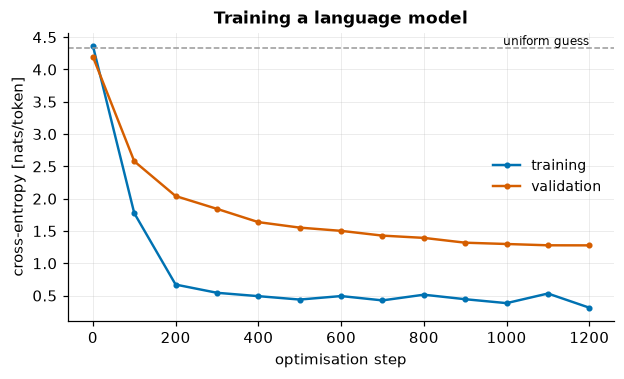

A uniform guess over 76 characters costs 4.331 nats (perplexity 76).
Our model reaches 1.278 nats (perplexity 3.59).

Perplexity is exp(cross-entropy): roughly 'how many characters is the model
effectively choosing between at each step'. Going from 76 to a handful means it
has learned the structure of the text.


In [7]:
def train_gpt(config: TinyGPTConfig, steps: int, batch_size: int = 32,
              learning_rate: float = 3e-3, label: str = "", seed: int = 0):
    """Train one model and return it with its loss history."""
    set_seed(seed)
    model = TinyGPT(config)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
    schedule = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=learning_rate, total_steps=steps, pct_start=0.1
    )
    gen = torch.Generator().manual_seed(seed)
    curve, started = [], time.perf_counter()

    for step in range(steps):
        model.train()
        x, y = get_batch(train_data, batch_size, config.context, gen)
        _, loss = model(x, targets=y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        schedule.step()

        if step % max(steps // 12, 1) == 0 or step == steps - 1:
            model.eval()
            with torch.no_grad():
                eval_gen = torch.Generator().manual_seed(1234)
                validation = np.mean([
                    float(model(*get_batch(valid_data, batch_size, config.context, eval_gen))[1])
                    for _ in range(6)
                ])
            curve.append({"step": step, "train": float(loss.detach()),
                          "validation": float(validation)})
    seconds = time.perf_counter() - started
    if label:
        print(f"{label:26s} params {count_parameters(model):8,}  {seconds:6.1f}s  "
              f"final val loss {curve[-1]['validation']:.3f}  "
              f"perplexity {math.exp(curve[-1]['validation']):6.2f}")
    return model, pd.DataFrame(curve), seconds


STEPS = scaled(full=1200, fast=60)
MAIN_SIZE = (4, 128)          # (layers, d_model); reused as the top scaling point
config = TinyGPTConfig(vocab_size=tokenizer.vocab_size, context=CONTEXT,
                       d_model=MAIN_SIZE[1], n_heads=4, n_layers=MAIN_SIZE[0], dropout=0.1)
model, curve, train_seconds = train_gpt(
    config, STEPS, label=f"TinyGPT ({MAIN_SIZE[0]} layers, d={MAIN_SIZE[1]})")

tokens_seen = STEPS * 32 * CONTEXT
print(f"\nsaw {tokens_seen:,} tokens = {tokens_seen / len(text):.1f} passes over the corpus")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(curve.step, curve.train, label="training", color=COLORS["rnn"], marker="o", ms=3)
ax.plot(curve.step, curve.validation, label="validation", color=COLORS["transformer"],
        marker="o", ms=3)
ax.axhline(math.log(tokenizer.vocab_size), ls="--", color="#999", lw=1)
ax.text(curve.step.iloc[-1], math.log(tokenizer.vocab_size),
        " uniform guess", va="bottom", ha="right", fontsize=8)
ax.set_xlabel("optimisation step")
ax.set_ylabel("cross-entropy [nats/token]")
ax.set_title("Training a language model")
ax.legend()
plt.show()

print(f"A uniform guess over {tokenizer.vocab_size} characters costs "
      f"{math.log(tokenizer.vocab_size):.3f} nats (perplexity {tokenizer.vocab_size}).")
print(f"Our model reaches {curve.validation.iloc[-1]:.3f} nats "
      f"(perplexity {math.exp(curve.validation.iloc[-1]):.2f}).")
print("\nPerplexity is exp(cross-entropy): roughly 'how many characters is the model")
print("effectively choosing between at each step'. Going from 76 to a handful means it")
print("has learned the structure of the text.")

## 8. What it writes

Sampling, at several temperatures, from the same prompt.

In [8]:
def complete(prompt: str, max_new_tokens: int = 240, **kwargs) -> str:
    ids = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long)
    out = generate(model, ids, max_new_tokens=max_new_tokens,
                   generator=torch.Generator().manual_seed(7), **kwargs)
    return tokenizer.decode(out[0])


PROMPT = "LOG 0"
for temperature, description in [
    (0.0, "greedy (argmax) — deterministic, repetitive"),
    (0.5, "low temperature — conservative"),
    (0.8, "moderate"),
    (1.3, "high temperature — varied, error-prone"),
]:
    print("=" * 78)
    print(f"temperature = {temperature}   {description}")
    print("=" * 78)
    print(complete(PROMPT, max_new_tokens=200, temperature=temperature))
    print()

temperature = 0.0   greedy (argmax) — deterministic, repetitive


LOG 02:11 Sudwerk 380 kV | load 1110.8 MW | voltage 1.01 pu | loading 107.8 percent | line returned to service.
LOG 11:59 Sudwerk 220 kV | load 110.8 MW | voltage 1.002 pu | loading 103.1 percent | line re

temperature = 0.5   low temperature — conservative


LOG 07:06 Steinbruck 380 kV | load 3004.4 MW | voltage 1.029 pu | loading 53.3 percent | tap changer adjusted.
LOG 14:07 Steinbruck 220 kV | load 248.6 MW | voltage 1.035 pu | loading 86.9 percent | line r

temperature = 0.8   moderate


LOG 07:06 Steinbruck 380 kV | load 3004.4 MW | voltage 1.029 pu | loading 53.3 percent | tap changer adjusted.
LOG 14:07 Steinbruck 220 kV | load 248.6 MW | voltage 1.035 pu | loading 86.9 percent | genera

temperature = 1.3   high temperature — varied, error-prone


LOG 07:06 Steinbruck 110 kV | load 30.4 MW | voltage 0.97 pu | loading 75.5 percent | auto-reclose successful.
LOG 14:07 Steinbruck 220 kV | load 248.6 MW | voltage 1.045 pu | loading 86.9 percent | genera



Those completions look far more alike than the temperature labels suggest,
and that is itself the lesson: when a model is *confident*, temperature has
little to reshape. Rather than eyeball it, measure the diversity across
several samples per temperature.

In [9]:
def diversity(temperature: float, n_samples: int = 6, length: int = 120) -> tuple[int, float]:
    """How many distinct completions, and how similar are they character by character?"""
    samples = []
    for seed in range(n_samples):
        ids = torch.tensor([tokenizer.encode(PROMPT)], dtype=torch.long)
        out = generate(model, ids, max_new_tokens=length, temperature=temperature,
                       generator=torch.Generator().manual_seed(seed))
        samples.append(tokenizer.decode(out[0])[len(PROMPT):])
    pairs = [
        np.mean([a == b for a, b in zip(x, y, strict=False)])
        for i, x in enumerate(samples) for y in samples[i + 1:]
    ]
    return len(set(samples)), float(np.mean(pairs))


print(f"{'temperature':>12} {'distinct of 6':>14} {'mean pairwise agreement':>25}")
for temperature in (0.2, 0.5, 0.8, 1.0, 1.3, 1.8):
    distinct, agreement = diversity(temperature)
    print(f"{temperature:12.1f} {distinct:14d} {agreement:24.1%}")

print("\nDiversity rises monotonically with temperature, but slowly at first: the")
print("structure of a log entry is so predictable that the model is near-certain about")
print("most characters, and only the digits and the free-text ending have real entropy.")
print("A model trained on a more varied corpus would spread out much faster.")

 temperature  distinct of 6   mean pairwise agreement


         0.2              6                    25.5%


         0.5              6                    14.1%


         0.8              6                    16.1%


         1.0              6                    15.8%


         1.3              6                    15.7%


         1.8              6                     8.9%

Diversity rises monotonically with temperature, but slowly at first: the
structure of a log entry is so predictable that the model is near-certain about
most characters, and only the digits and the free-text ending have real entropy.
A model trained on a more varied corpus would spread out much faster.


### Temperature, top-k and top-p

All three reshape the distribution before sampling; none of them change the
model.

- **Temperature** $T$ divides the logits. $T<1$ sharpens (conservative,
  repetitive), $T>1$ flattens (varied, error-prone), $T=0$ is greedy.
- **Top-k** keeps the $k$ most likely tokens.
- **Top-p (nucleus)** keeps the smallest set whose probability mass exceeds
  $p$ — so it adapts to how confident the model is at that step.

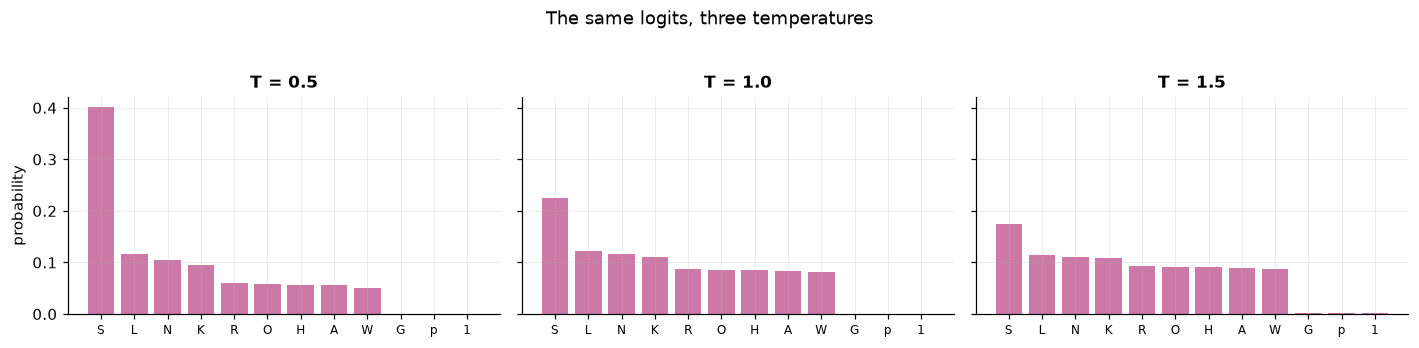

  top-p = 0.50  keeps   4 of 76 characters
  top-p = 0.90  keeps   8 of 76 characters
  top-p = 0.95  keeps   9 of 76 characters
  top-p = 0.99  keeps   9 of 76 characters

At this step the model is confident, so the nucleus is small. At an uncertain
step it would widen automatically — which is the argument for top-p over top-k.


In [10]:
prompt_ids = torch.tensor([tokenizer.encode("DISTURBANCE REPORT\n  location    : ")],
                          dtype=torch.long)
model.eval()
with torch.no_grad():
    logits, _ = model(prompt_ids[:, -config.context :])
next_logits = logits[0, -1]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.0), sharey=True)
for ax, temperature in zip(axes, (0.5, 1.0, 1.5), strict=True):
    probabilities = torch.softmax(next_logits / temperature, dim=-1).numpy()
    order = np.argsort(probabilities)[::-1][:12]
    ax.bar([tokenizer.itos[int(i)].replace("\n", "\\n") for i in order],
           probabilities[order], color=COLORS["foundation"])
    ax.set_title(f"T = {temperature}")
    ax.tick_params(axis="x", labelsize=8)
axes[0].set_ylabel("probability")
fig.suptitle("The same logits, three temperatures", y=1.04)
fig.tight_layout()
plt.show()

probabilities = torch.softmax(next_logits, dim=-1)
sorted_probabilities = torch.sort(probabilities, descending=True).values
for p in (0.5, 0.9, 0.95, 0.99):
    nucleus = int((sorted_probabilities.cumsum(0) < p).sum()) + 1
    print(f"  top-p = {p:.2f}  keeps {nucleus:3d} of {tokenizer.vocab_size} characters")
print("\nAt this step the model is confident, so the nucleus is small. At an uncertain")
print("step it would widen automatically — which is the argument for top-p over top-k.")

In [11]:
print("Top-k and top-p on the same prompt:\n")
for kwargs, label in [
    ({"temperature": 1.0}, "pure sampling"),
    ({"temperature": 1.0, "top_k": 5}, "top-k = 5"),
    ({"temperature": 1.0, "top_p": 0.9}, "top-p = 0.9"),
]:
    print(f"--- {label} ---")
    print(complete("ASSET ", max_new_tokens=150, **kwargs))
    print()

Top-k and top-p on the same prompt:

--- pure sampling ---


ASSET Kirchberg-20-circuit_breaker | commissioned 196 | rated 124.5 MVA | condition index 0.04 | next inspection 2029.
ASSET Steinbruck-380-disconnector | c

--- top-k = 5 ---


ASSET Kirchberg-20-circuit_breaker | commissioned 196 | rated 124.4 MVA | condition index 0.76 | next inspection 2029.
ASSET Steinbruck-380-disconnector | c

--- top-p = 0.9 ---


ASSET Kirchberg-20-circuit_breaker | commissioned 196 | rated 124.5 MVA | condition index 0.84 | next inspection 2026.
ASSET Steinbruck-380-disconnector | c



## 9. A scaling law, measured

Kaplan et al. found that test loss falls as a power law in model size, data
and compute. Our corpus is 270 kB rather than 300 GB, so we cannot reproduce
their constants — but we can reproduce the *shape*, which is the part worth
internalising.

L=1, d=32                  params   19,296    14.4s  final val loss 2.354  perplexity  10.53


L=2, d=64                  params  113,152    44.9s  final val loss 1.629  perplexity   5.10


L=3, d=96                  params  355,296   109.0s  final val loss 1.403  perplexity   4.07
L=4, d=128 (reused)        params  819,456   233.2s  final val loss 1.278


,layers,d_model,parameters,val loss,perplexity,train seconds
0,1,32,19296,2.354,10.528,14.4
1,2,64,113152,1.629,5.098,44.9
2,3,96,355296,1.403,4.068,109.0
3,4,128,819456,1.278,3.589,233.2


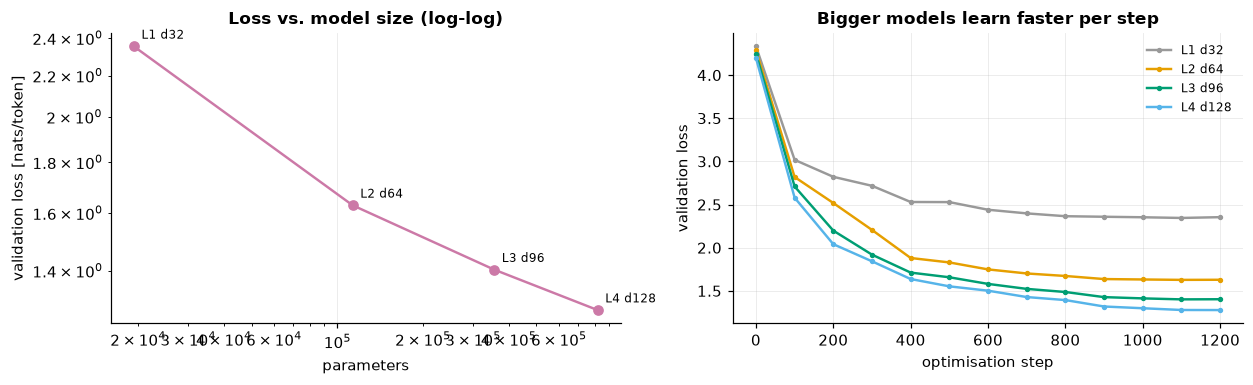

Fitted exponent: loss ~ N^-0.164
Kaplan et al. report about -0.076 for language models over seven orders of
magnitude. Our exponent comes from four points spanning less than two orders
of magnitude on a 270 kB corpus — the shape is real, the number is not
comparable, and reporting it as if it were would be exactly the kind of
over-reading this course keeps warning about.


In [12]:
# The main model above is the largest point, so it is not retrained here.
SMALLER = [(1, 32), (2, 64), (3, 96)] if not fast_mode() else [(1, 32)]
scaling_rows = []
scaling_curves = {}

for n_layers, d_model in [*SMALLER, MAIN_SIZE]:
    if (n_layers, d_model) == MAIN_SIZE:
        candidate, candidate_curve, seconds = model, curve, train_seconds
        print(f"{'L=4, d=128 (reused)':26s} params {count_parameters(candidate):8,}  "
              f"{seconds:6.1f}s  final val loss {candidate_curve.validation.iloc[-1]:.3f}")
    else:
        small_config = TinyGPTConfig(vocab_size=tokenizer.vocab_size, context=CONTEXT,
                                     d_model=d_model, n_heads=max(d_model // 32, 1),
                                     n_layers=n_layers, dropout=0.1)
        candidate, candidate_curve, seconds = train_gpt(
            small_config, STEPS, label=f"L={n_layers}, d={d_model}")
    scaling_rows.append({
        "layers": n_layers,
        "d_model": d_model,
        "parameters": count_parameters(candidate),
        "val loss": candidate_curve.validation.iloc[-1],
        "perplexity": math.exp(candidate_curve.validation.iloc[-1]),
        "train seconds": round(seconds, 1),
    })
    scaling_curves[f"L{n_layers} d{d_model}"] = candidate_curve

scaling = pd.DataFrame(scaling_rows)
display(scaling.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
axes[0].loglog(scaling.parameters, scaling["val loss"], marker="o", color=COLORS["foundation"])
for _, row in scaling.iterrows():
    axes[0].annotate(f"L{int(row.layers)} d{int(row.d_model)}",
                     (row.parameters, row["val loss"]), fontsize=8,
                     textcoords="offset points", xytext=(5, 5))
axes[0].set_xlabel("parameters")
axes[0].set_ylabel("validation loss [nats/token]")
axes[0].set_title("Loss vs. model size (log-log)")
for label, candidate_curve in scaling_curves.items():
    axes[1].plot(candidate_curve.step, candidate_curve.validation, label=label, marker="o", ms=2.5)
axes[1].set_xlabel("optimisation step")
axes[1].set_ylabel("validation loss")
axes[1].set_title("Bigger models learn faster per step")
axes[1].legend(fontsize=8)
fig.tight_layout()
plt.show()

if len(scaling) >= 3:
    slope, intercept = np.polyfit(np.log(scaling.parameters), np.log(scaling["val loss"]), 1)
    print(f"Fitted exponent: loss ~ N^{slope:.3f}")
    print("Kaplan et al. report about -0.076 for language models over seven orders of")
    print("magnitude. Our exponent comes from four points spanning less than two orders")
    print("of magnitude on a 270 kB corpus — the shape is real, the number is not")
    print("comparable, and reporting it as if it were would be exactly the kind of")
    print("over-reading this course keeps warning about.")

### What scaling does not give you

Our largest model has the lowest loss. It is still not a foundation model, and
the reason is worth stating precisely:

1. **The pretraining distribution is one narrow corpus.** A foundation model is
   defined by the *breadth* it was pretrained on, not by its size. Scaling a
   model on 270 kB of substation logs produces an excellent substation-log
   model and nothing else.
2. **It cannot be adapted to a new task.** There is no in-context learning
   here, no instruction following, and nothing a downstream head could usefully
   attach to.
3. **Loss is not capability.** Lower cross-entropy on held-out text of the same
   kind says the model fits this distribution better. It says nothing about
   whether it can do anything.

Tutorial 09 makes this the central argument. **Large is not the same as
foundational**, and the clearest counter-examples are in the other direction:
TabPFN and WindFM are foundation models with a few million parameters.

## 10. Failure analysis: hallucination in miniature

Our model emits confident, well-formatted records that are entirely invented.
That is not a bug — it is the objective working as specified. The model was
trained to produce *likely* text, and there is no term anywhere in the loss for
*true* text.

In [13]:
generated = complete("DISTURBANCE REPORT\n  location    : ", max_new_tokens=320,
                     temperature=0.7, top_p=0.9)
print(generated)
print("\n" + "=" * 78)

known_substations = ["Nordfeld", "Ostkamp", "Lindenau", "Sudwerk", "Altbach",
                     "Rheinhof", "Kirchberg", "Weidental", "Hochmoor", "Steinbruck"]
found = [s for s in known_substations if s in generated]
print(f"substation names from the corpus appearing in the output: {found or 'none'}")
print("\nEverything above is fabricated. The format is right, the vocabulary is right,")
print("the numbers are plausible — and no such event occurred, because no such")
print("substation exists. A larger model fabricates more fluently, not less.")

DISTURBANCE REPORT
  location    : Ostkamp 30 kV
  equipment   : busbar
  cause       : equipment ageing
  weather    : light rain
  duration    : 127 minutes
  customers   : 284
  energy not supplied : 11.7 MWh
  remedial action : capacitor bank connected.

DISTURBANCE REPORT
  location    : Ostkamp 220 kV
  equipment   : capacitor bank
  cause       :

substation names from the corpus appearing in the output: ['Ostkamp']

Everything above is fabricated. The format is right, the vocabulary is right,
the numbers are plausible — and no such event occurred, because no such
substation exists. A larger model fabricates more fluently, not less.


Three distinctions that tutorial 08 will build on:

- **Parametric knowledge** lives in the weights. It is whatever the training
  data happened to contain, compressed lossily, with no provenance and no way
  to tell recall from invention.
- **Retrieved knowledge** is put into the context at query time. It has a
  source you can check.
- **Tool output** comes from running something — a power flow, a database
  query — and is as reliable as the tool.

For engineering use the second and third are usually what you want. The first
is a plausible-text generator that happens to be right a lot of the time.

In [14]:
# How much of the model's output is memorised rather than composed?
def longest_common_substring(a: str, b: str, minimum: int = 12) -> str:
    """Longest run of the generation that appears verbatim in the corpus."""
    best = ""
    for start in range(len(a)):
        for end in range(start + len(best) + 1, len(a) + 1):
            if a[start:end] in b:
                best = a[start:end]
            else:
                break
    return best if len(best) >= minimum else ""


sample = complete("LOG 1", max_new_tokens=200, temperature=0.8)
overlap = longest_common_substring(sample, text)
print(f"longest verbatim overlap with the corpus: {len(overlap)} characters")
print(f"  {overlap!r}")
print(f"\nThe generation is {len(sample)} characters long, so roughly "
      f"{len(overlap) / len(sample):.0%} of it is the longest copied run.")
print("With a 270 kB corpus and a rigid template, substantial verbatim overlap is")
print("expected and is not evidence of understanding. Memorisation is also a real")
print("privacy concern at scale: large models have been shown to emit training data")
print("verbatim, which matters if you ever fine-tune on operational records.")

longest verbatim overlap with the corpus: 41 characters
  '3.3 percent | tap changer adjusted.\nLOG 1'

The generation is 205 characters long, so roughly 20% of it is the longest copied run.
With a 270 kB corpus and a rigid template, substantial verbatim overlap is
expected and is not evidence of understanding. Memorisation is also a real
privacy concern at scale: large models have been shown to emit training data
verbatim, which matters if you ever fine-tune on operational records.


## 11. From this to a modern LLM

Everything you have just built, at scale, plus three steps we have not done:

| stage | what changes | our model |
|---|---|---|
| **pretraining** | trillions of tokens, thousands of GPUs | 270 kB, one CPU, 90 seconds |
| **instruction tuning** | supervised fine-tuning on (instruction, response) pairs | not done |
| **preference optimisation** | RLHF (Ouyang et al., 2022) or DPO (Rafailov et al., 2023) | not done |
| **inference-time scaffolding** | tools, retrieval, agents, long context | tutorial 08 |

The second and third are why ChatGPT answers questions while GPT-3 continued
your text. A base model is a *text completer*; instruction tuning is what makes
it a *responder*. That distinction explains a lot of confusing LLM behaviour
and is invisible if you have only ever used a chat interface.

Other terms you will meet, none of which changes the picture above:
**mixture of experts** (route each token through a subset of the parameters),
**quantization** (store weights in 8 or 4 bits), **context extension** (RoPE
scaling and friends), and **speculative decoding** (draft with a small model,
verify with a large one).

## 12. Exercises

**1 — Conceptual.** Our model's loss keeps falling as it gets larger, and its
generations get more plausible. Design an evaluation that would distinguish
"has learned the structure of a disturbance report" from "has memorised the
corpus". Your design should produce a number, not an impression. Then argue
what the equivalent test would be for a model claimed to "understand power
systems", and why benchmark contamination makes that hard to run on a public
LLM.

**2 — Coding.** Replace the character tokenizer with the subword tokenizer
from section 5 and retrain at the same parameter budget. Compare validation
loss *per character* (not per token — the units differ, and this is the trap).
Which wins, and how does the answer depend on the corpus size? Explain the
result in terms of what each tokenizer forces the model to learn.

**3 — Research.** The model fabricates confidently. Implement a simple
*grounding* check: after generating a disturbance report, verify each field
against the corpus (does the substation exist, is the equipment type in the
vocabulary, is the duration in the observed range) and report the fraction of
fields that are supported. Then read about retrieval-augmented generation
(Lewis et al., 2020) and explain which of your failures RAG would fix and
which it would not. Tutorial 08 builds the retrieval half.

## 13. Key takeaways

- **A language model is the tutorial-06 Transformer with a causal mask and a
  vocabulary.** Nothing else was added.
- **Teacher forcing makes the supervision free**: one forward pass over $T$
  positions gives $T$ training signals, which is why the objective scales.
- **Tokenization is a design decision with consequences** — sequence length,
  embedding size, and how the model handles numbers.
- **Temperature, top-k and top-p reshape the output distribution**; they do not
  change what the model knows.
- **Loss falls predictably with scale**, and we measured the shape. But a
  larger model trained on one narrow corpus is still not a foundation model —
  breadth of pretraining, not parameter count, is what earns that name.
- **Fabrication is the objective working correctly.** Nothing in the loss
  rewards truth. Grounding has to come from outside the weights.

## 14. Further reading

- Radford et al., "Improving Language Understanding by Generative
  Pre-Training" (GPT-1, 2018) and "Language Models are Unsupervised Multitask
  Learners" (GPT-2, 2019).
- Brown et al., "Language Models are Few-Shot Learners" (GPT-3),
  [arXiv:2005.14165](https://arxiv.org/abs/2005.14165).
- Kaplan et al., "Scaling Laws for Neural Language Models",
  [arXiv:2001.08361](https://arxiv.org/abs/2001.08361); then Hoffmann et al.,
  "Training Compute-Optimal Large Language Models",
  [arXiv:2203.15556](https://arxiv.org/abs/2203.15556).
- Ouyang et al., "Training language models to follow instructions with human
  feedback", [arXiv:2203.02155](https://arxiv.org/abs/2203.02155).
- Carlini et al., "Extracting Training Data from Large Language Models",
  [arXiv:2012.07805](https://arxiv.org/abs/2012.07805) — the memorisation
  result behind section 10.
- Karpathy, "Let's build GPT: from scratch, in code, spelled out" —
  `TinyGPT` follows this closely.
  <https://www.youtube.com/watch?v=kCc8FmEb1nY>

---

**Next:** [Tutorial 08 — Using Modern LLMs](08_pretrained_llms_and_adaptation.ipynb).
We stop training models from scratch and start reusing ones that already exist.